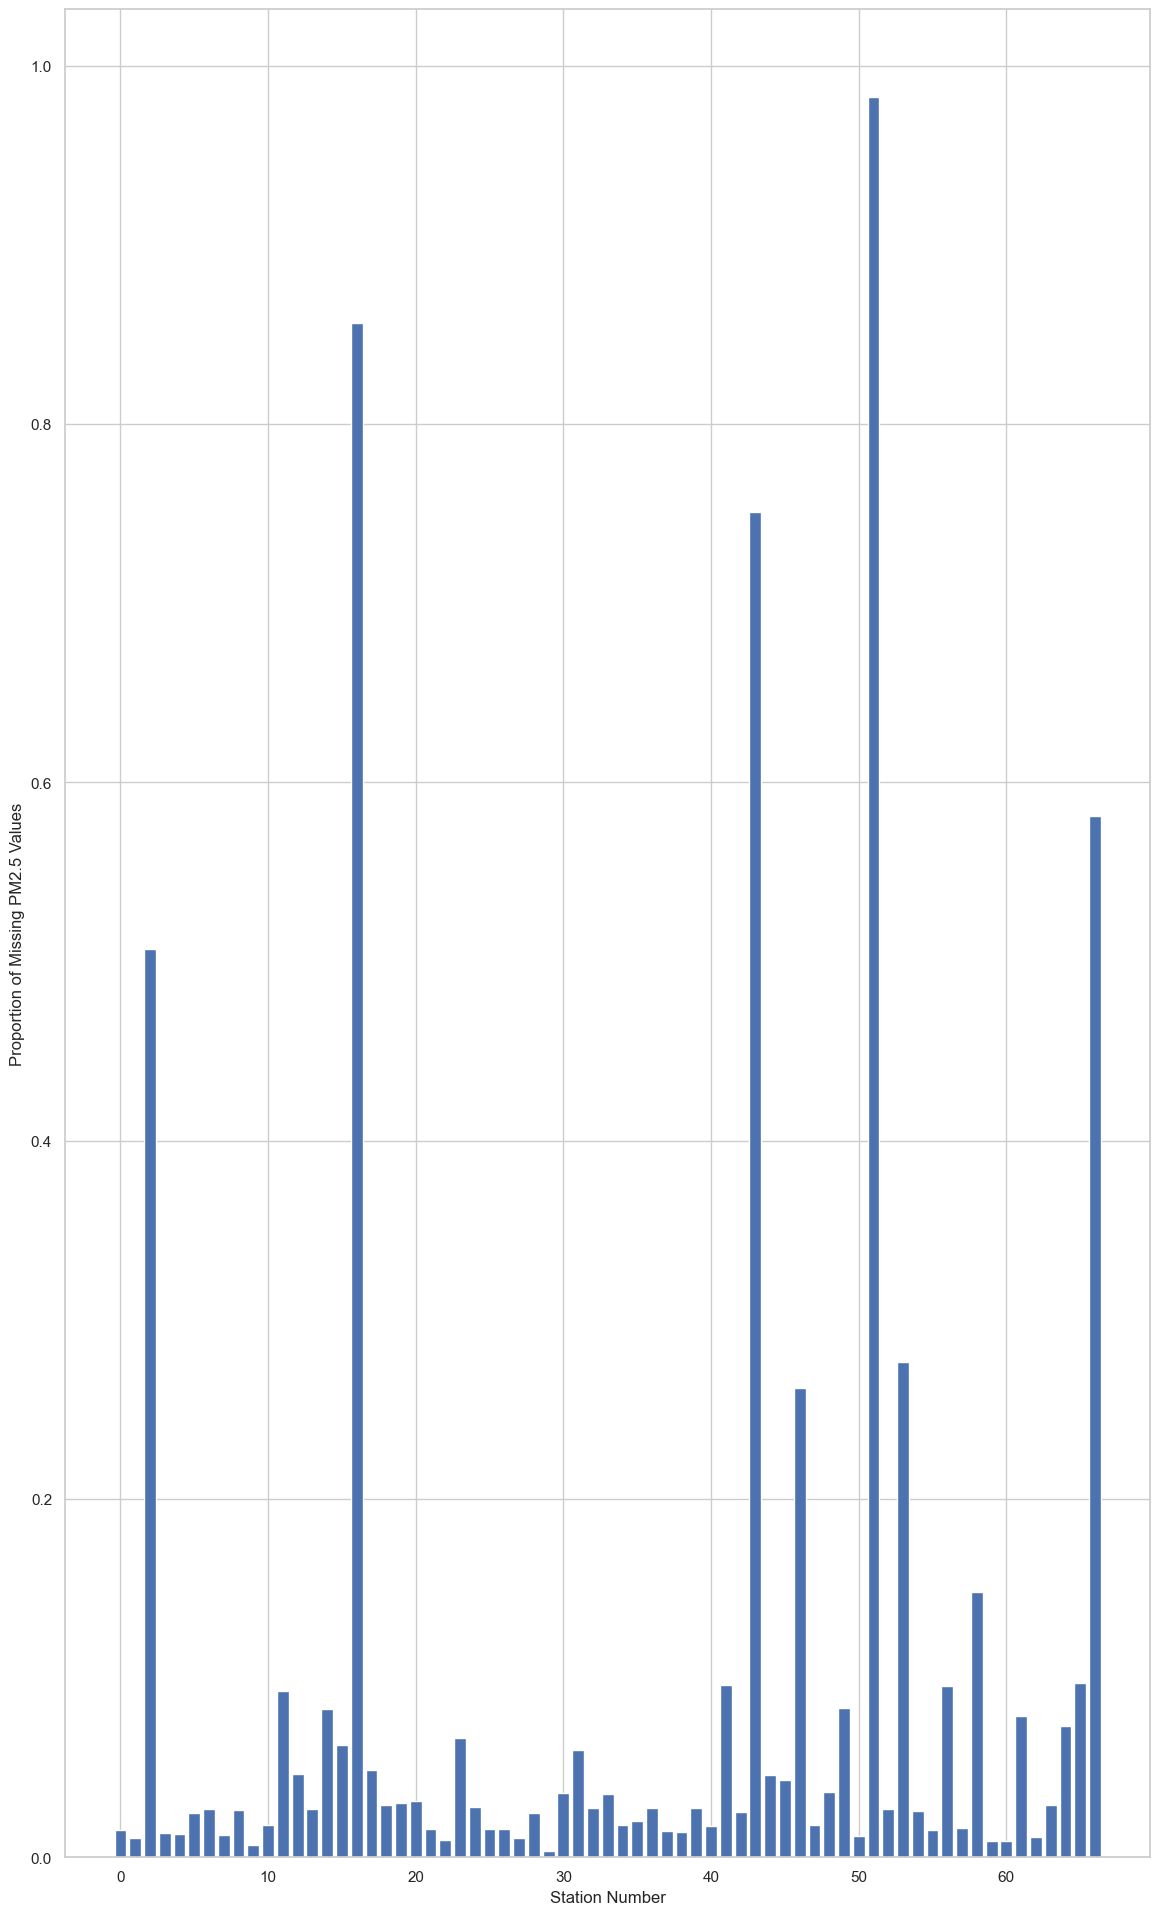

Number of stations after cleaning: 60


In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import matplotlib.dates as mdates # Essential for custom date ticks

# %%
BCdata = pd.read_csv('../Dataset/Air Pollutant Data/_processed/BC_2022_2025_combined.csv', header=0)

# %%
# find and remove duplicated rows
BCdata = BCdata.drop_duplicates()

# %%
# Create a function to convert time to 24-hour format
def convert_to_24h(time_str):
    time_part, am_pm = time_str.split(' ')
    hours, minutes = map(int, time_part.split(':'))
    
    # Handle "24:00 AM" as special case
    if hours == 24 and am_pm == 'AM':
        return "00:00"
    
    # Convert to 24-hour format
    if am_pm == 'PM' and hours != 12:
        hours += 12
    elif am_pm == 'AM' and hours == 12:
        hours = 0
    
    return f"{hours:02d}:{minutes:02d}"

# Apply conversion
BCdata['Time_24h'] = BCdata['Time'].apply(convert_to_24h)

# Now combine date and 24-hour time
BCdata['datetime'] = pd.to_datetime(BCdata['Date'] + ' ' + BCdata['Time_24h'], format='%m/%d/%Y %H:%M')

BCdata.drop(columns=['Time_24h', 'Date', 'Time'], inplace=True)

# %%
station_groups = {}
for station_name, station_data in BCdata.groupby('Station'):
    station_groups[station_name] = station_data

# %% [markdown]
# ## 1. missing value analysis

# %%
# find nans in each station
nans_list = []
station_names = []
for station_name, station_data in station_groups.items():
    nans = station_data.isna().sum()['PM25']/len(station_data)
    station_names.append(station_name)
    nans_list.append(nans)
        
plt.bar(np.arange(len(nans_list)), nans_list)
plt.xlabel('Station Number') 
plt.ylabel('Proportion of Missing PM2.5 Values')
plt.show()

# %%
# drop stations with more than 20% missing values
stations_to_keep = [station_name for station_name, nans in zip(station_names, nans_list) if nans <= 0.2]
cleaned_data = BCdata[BCdata['Station'].isin(stations_to_keep)].reset_index(drop=True)
print(f"Number of stations after cleaning: {len(stations_to_keep)}")

cleaned_station_groups = {}
for station_name, station_data in cleaned_data.groupby('Station'):
    cleaned_station_groups[station_name] = station_data

In [148]:
# ## 2. Presentation Storyline Analysis (2022-2025)
# **Goal:** Visualization with distinct seasonal contexts and rush hour highlights.

# %%
# --- 1. Data Preparation for Visualization ---

# Define the target years for analysis. We focus on 2022-2025 to capture post-pandemic trends.
target_years = [2022, 2023, 2024, 2025]

# Filter the dataset to include only rows where the year matches our target list.
cleaned_data = cleaned_data[cleaned_data['datetime'].dt.year.isin(target_years)]

# Feature Engineering: Extract time-based features from the datetime column for grouping.
cleaned_data['hour'] = cleaned_data['datetime'].dt.hour           # 0-23 hour
cleaned_data['day_of_week'] = cleaned_data['datetime'].dt.day_name() # Monday, Tuesday...
cleaned_data['month'] = cleaned_data['datetime'].dt.month_name()  # January, February...
cleaned_data['year'] = cleaned_data['datetime'].dt.year           # 2022, 2023...

# Define weekends: 5 represents Saturday, 6 represents Sunday.
cleaned_data['is_weekend'] = cleaned_data['datetime'].dt.dayofweek.isin([5, 6])
# Create a readable 'Day Type' column based on the weekend boolean.
cleaned_data['day_type'] = cleaned_data['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

# Define specific sort orders for days and months to ensure charts plot chronologically, not alphabetically.
week_order = list(calendar.day_name)          # [Monday, Tuesday, ..., Sunday]
month_order = list(calendar.month_name)[1:]   # [January, February, ..., December]

# Set the visual style for all seaborn plots to a clean white grid.
sns.set_theme(style="whitegrid")


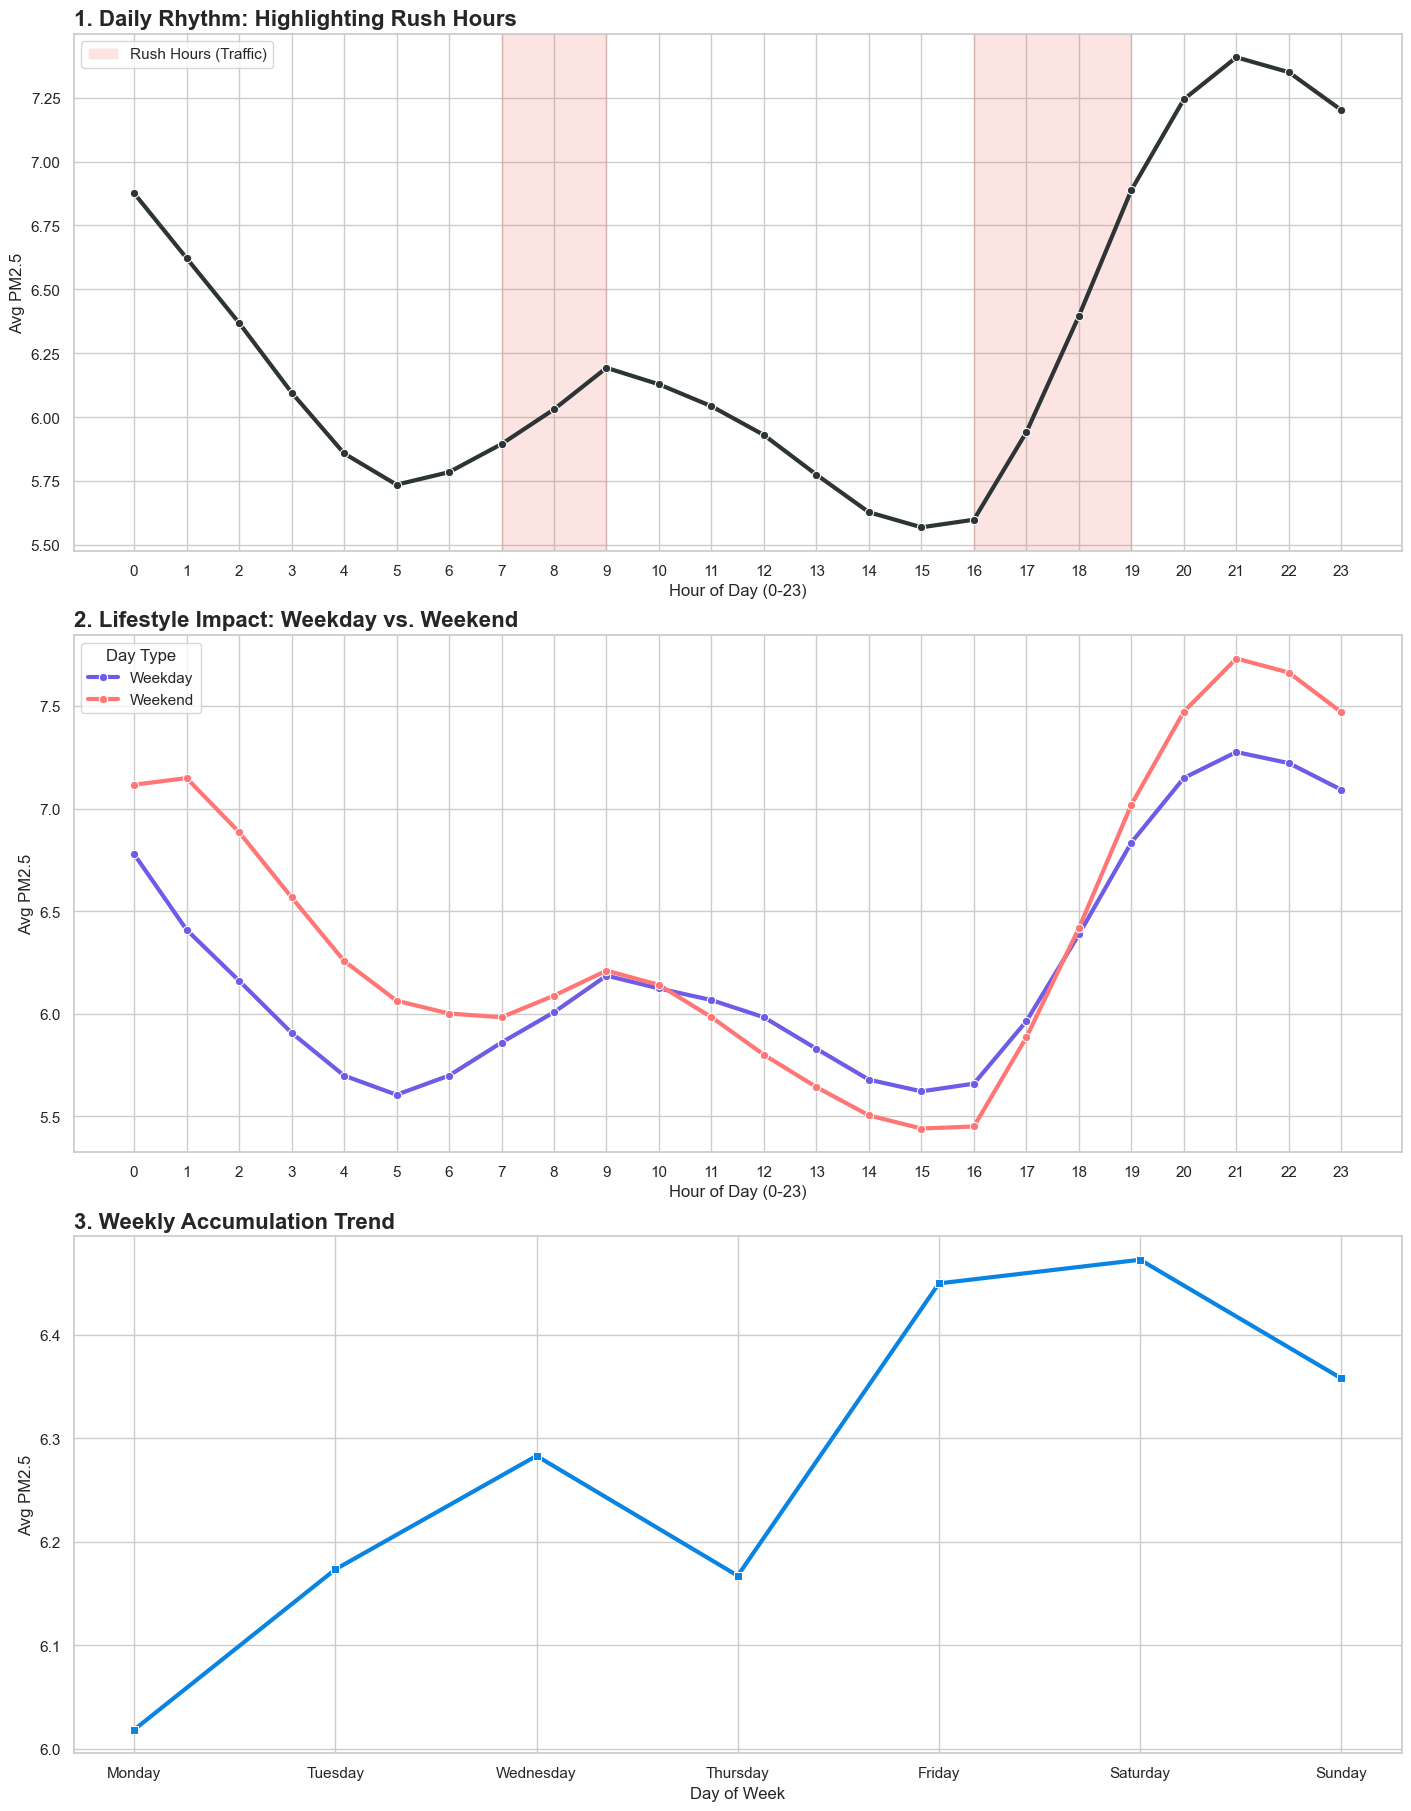

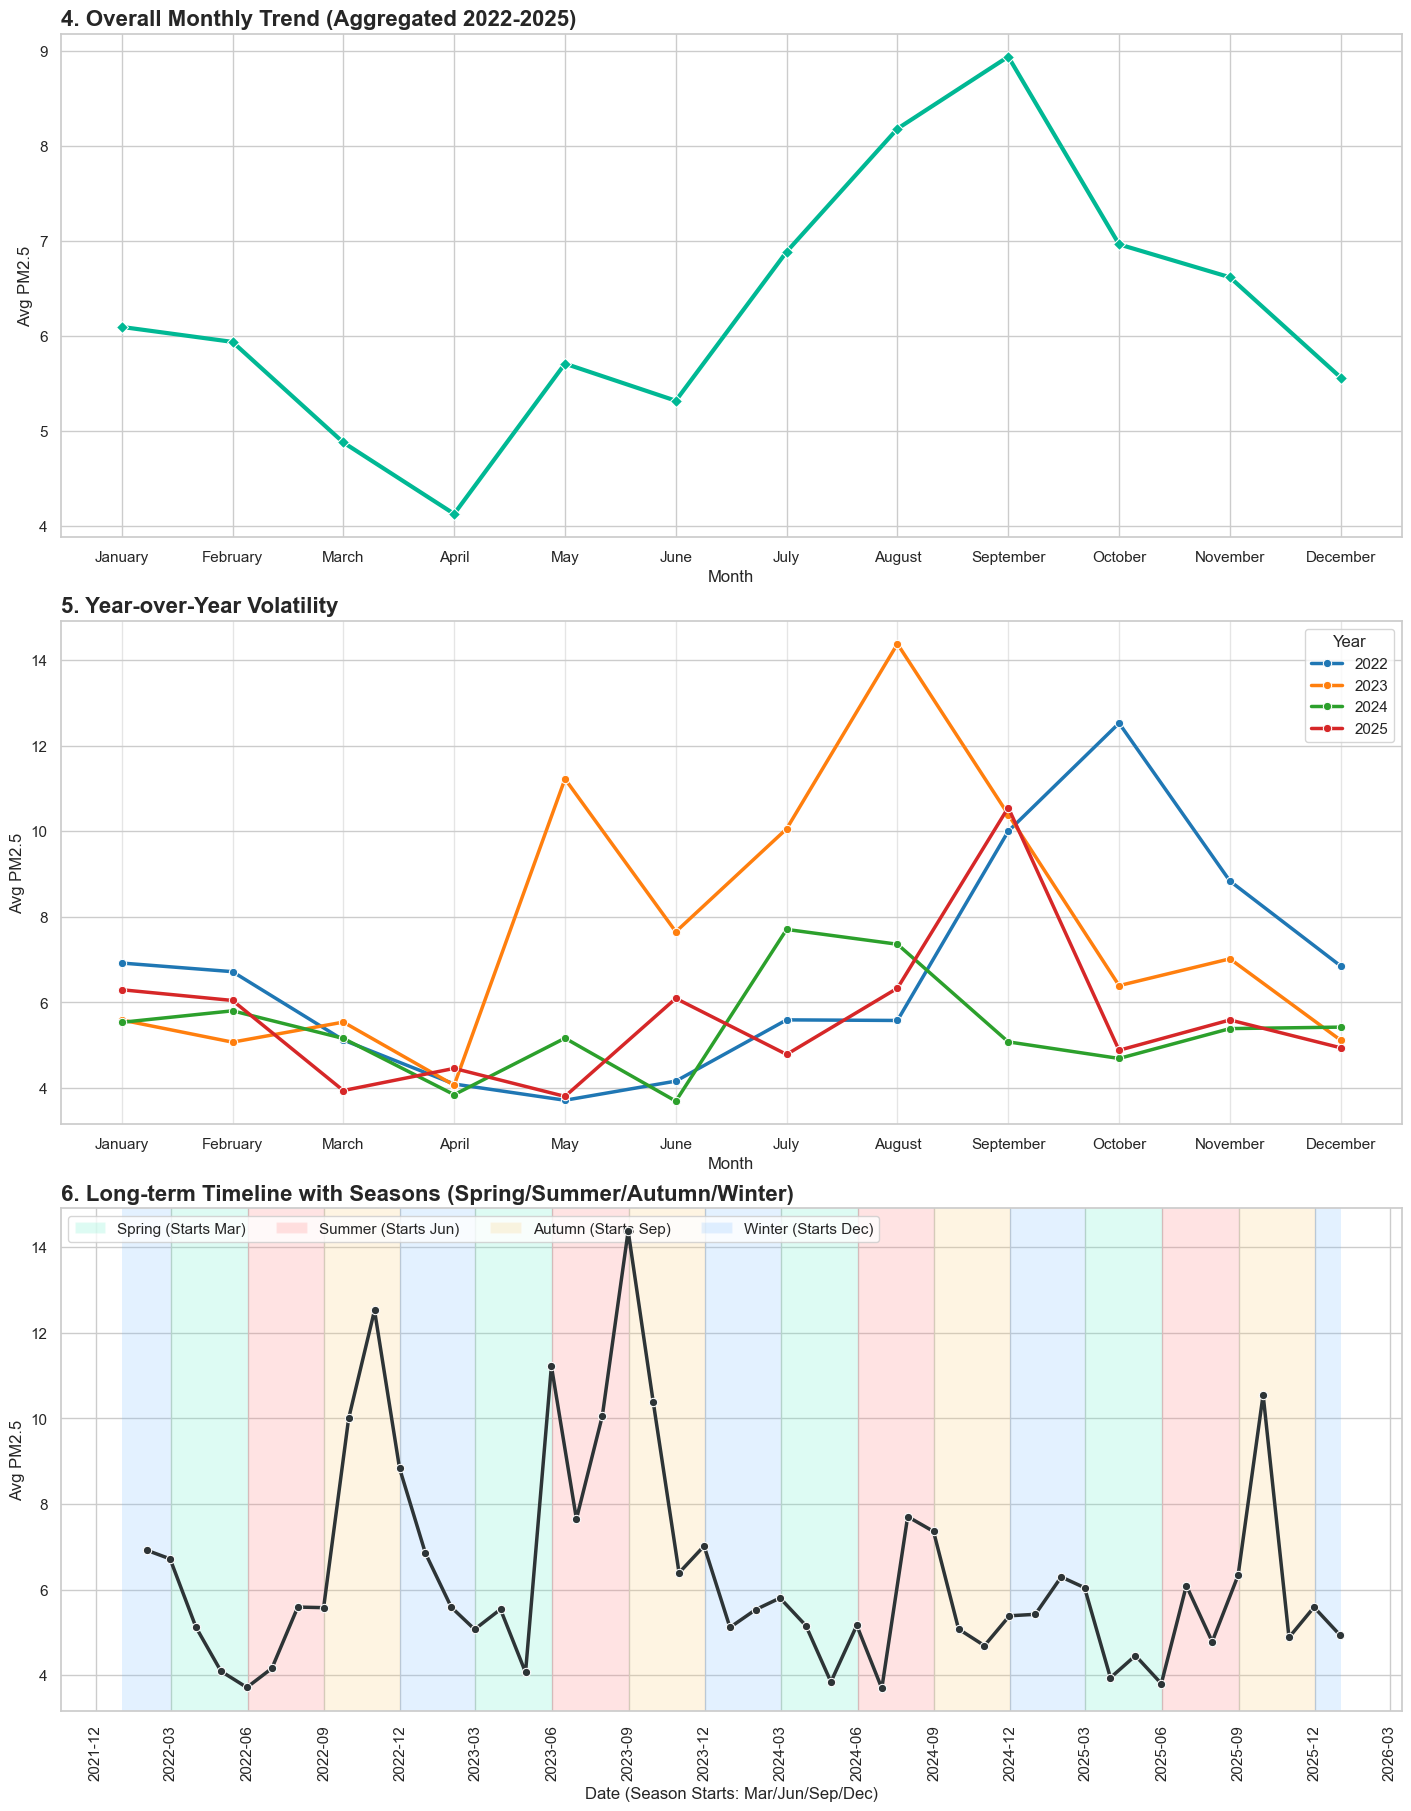

In [149]:
# ### ACT 1: The Human Fingerprint (Micro-Analysis)
# **Goal:** Visualize daily and weekly patterns driven by human activity (traffic, lifestyle).
# **Update:** Highlighting only "Rush Hours" in red.

# %%
# Create a figure with 3 subplots arranged vertically (3 rows, 1 column).
# figsize is set to (14, 18) to ensure each chart is tall enough to be readable.
fig1, axes1 = plt.subplots(3, 1, figsize=(14, 18), constrained_layout=True)

# ---------------------------------------------------------
# Chart 1: Daily Cycle (Hourly Average)
# ---------------------------------------------------------
# Calculate the mean PM2.5 concentration for each hour of the day (0-23).
hourly_avg = cleaned_data.groupby('hour')['PM25'].mean().reset_index()

# Plot the hourly trend.
sns.lineplot(
    data=hourly_avg, x='hour', y='PM25', 
    ax=axes1[0],             # Plot on the first subplot
    marker='o',              # Add circles at data points
    color='#2d3436',         # Dark grey line color
    linewidth=3,             # Thicker line for visibility
    zorder=10                # Ensure line stays on top of background shading
)

# Set chart title and labels.
axes1[0].set_title('1. Daily Rhythm: Highlighting Rush Hours', fontsize=16, fontweight='bold', loc='left')
axes1[0].set_xlabel('Hour of Day (0-23)')
axes1[0].set_xticks(range(0, 24))  # Ensure every hour is labeled on x-axis
axes1[0].set_ylabel('Avg PM2.5')

# >>>> Highlight Rush Hour Regions (Red Background) <<<<
# Morning Rush: 7 AM to 9 AM
axes1[0].axvspan(7, 9, color='#e74c3c', alpha=0.15, label='Rush Hour')
# Evening Rush: 4 PM (16:00) to 7 PM (19:00)
axes1[0].axvspan(16, 19, color='#e74c3c', alpha=0.15)

# Create a custom legend element to explain the red background shading.
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', alpha=0.15, label='Rush Hours (Traffic)')
]
axes1[0].legend(handles=legend_elements, loc='upper left')

# ---------------------------------------------------------
# Chart 2: Weekday vs. Weekend Comparison
# ---------------------------------------------------------
# Group data by both 'hour' and 'day_type' (Weekday/Weekend) to compare patterns.
split_avg = cleaned_data.groupby(['hour', 'day_type'])['PM25'].mean().reset_index()

# Plot two lines (hue='day_type') on the second subplot.
sns.lineplot(
    data=split_avg, x='hour', y='PM25', hue='day_type',
    ax=axes1[1], 
    marker='o', 
    palette={'Weekday': '#6c5ce7', 'Weekend': '#ff7675'}, # Purple for Weekday, Pink for Weekend
    linewidth=3
)

axes1[1].set_title('2. Lifestyle Impact: Weekday vs. Weekend', fontsize=16, fontweight='bold', loc='left')
axes1[1].set_xlabel('Hour of Day (0-23)')
axes1[1].set_xticks(range(0, 24))
axes1[1].set_ylabel('Avg PM2.5')
axes1[1].legend(title='Day Type') # Add legend to distinguish lines

# ---------------------------------------------------------
# Chart 3: Weekly Accumulation Trend
# ---------------------------------------------------------
# Calculate the average PM2.5 for each day of the week.
# .reindex(week_order) ensures Monday comes first, Sunday last.
weekly_avg = cleaned_data.groupby('day_of_week')['PM25'].mean().reindex(week_order).reset_index()

# Plot the weekly trend on the third subplot.
sns.lineplot(
    data=weekly_avg, x='day_of_week', y='PM25', 
    ax=axes1[2], 
    marker='s',        # Square markers
    color='#0984e3',   # Blue line
    linewidth=3
)

axes1[2].set_title('3. Weekly Accumulation Trend', fontsize=16, fontweight='bold', loc='left')
axes1[2].set_xlabel('Day of Week')
axes1[2].set_ylabel('Avg PM2.5')
axes1[2].grid(True, axis='x') # Add vertical grid lines for easier reading

# Save and display the Act 1 figure.
plt.savefig('Act1_Human_Fingerprint_Final.png', dpi=300)
plt.show()

# %% [markdown]
# ### ACT 2: The Seasonal & Event Context (Macro-Analysis)
# **Goal:** Visualize yearly and seasonal trends, distinguishing wildfires from weather stagnation.
# **Update:** X-axis labels strictly aligned to season start months (Mar, Jun, Sep, Dec).

# %%
# Create a figure with 3 subplots for the Macro-Analysis.
fig2, axes2 = plt.subplots(3, 1, figsize=(14, 18), constrained_layout=True)

# ---------------------------------------------------------
# Chart 4: Overall Monthly Trend (Aggregated)
# ---------------------------------------------------------
# Calculate the monthly average across all years combined.
# This chart can be misleading as it averages extreme years with normal years.
monthly_avg = cleaned_data.groupby('month')['PM25'].mean().reindex(month_order).reset_index()

sns.lineplot(
    data=monthly_avg, x='month', y='PM25', 
    ax=axes2[0], 
    marker='D',        # Diamond markers
    color='#00b894',   # Teal color
    linewidth=3
)

axes2[0].set_title('4. Overall Monthly Trend (Aggregated 2022-2025)', fontsize=16, fontweight='bold', loc='left')
axes2[0].set_xlabel('Month')
axes2[0].set_ylabel('Avg PM2.5')

# ---------------------------------------------------------
# Chart 5: Year-over-Year Volatility Comparison
# ---------------------------------------------------------
# Group by both Year and Month to see how each individual year behaved.
monthly_yearly_avg = cleaned_data.groupby(['year', 'month'])['PM25'].mean().reset_index()

# Ensure months are ordered Jan-Dec for plotting.
monthly_yearly_avg['month'] = pd.Categorical(
    monthly_yearly_avg['month'], categories=month_order, ordered=True
)

# Plot separate lines for each year using hue='year'.
sns.lineplot(
    data=monthly_yearly_avg, x='month', y='PM25', hue='year',
    ax=axes2[1], 
    marker='o', 
    palette='tab10',   # Standard distinct color palette
    linewidth=2.5
)

axes2[1].set_title('5. Year-over-Year Volatility', fontsize=16, fontweight='bold', loc='left')
axes2[1].set_xlabel('Month')
axes2[1].set_ylabel('Avg PM2.5')
axes2[1].legend(title='Year', loc='upper right')
axes2[1].grid(True, axis='x', alpha=0.5)

# ---------------------------------------------------------
# Chart 6: Long-term Timeline with Seasonal Backgrounds
# ---------------------------------------------------------
# Group data by Month End (freq='ME') to get a continuous timeline from 2022 to 2025.
long_term_trend = cleaned_data.groupby(pd.Grouper(key='datetime', freq='ME'))['PM25'].mean().reset_index()

sns.lineplot(
    data=long_term_trend, x='datetime', y='PM25',
    ax=axes2[2], 
    marker='o', 
    color='#2d3436', 
    linewidth=2.5, 
    zorder=10 # Ensure line is drawn on top of background colors
)

axes2[2].set_title('6. Long-term Timeline with Seasons (Spring/Summer/Autumn/Winter)', fontsize=16, fontweight='bold', loc='left')
axes2[2].set_xlabel('Date (Season Starts: Mar/Jun/Sep/Dec)')
axes2[2].set_ylabel('Avg PM2.5')

# >>>> Draw Seasonal Background Colors <<<<
# Define the start and end months for each season and their corresponding color.
seasons = [
    (1, 2, '#74b9ff', 'Winter'),   # Jan-Feb (Winter continues from previous Dec)
    (3, 5, '#55efc4', 'Spring'),   # Mar-May
    (6, 8, '#ff7675', 'Summer'),   # Jun-Aug (Wildfire Season)
    (9, 11, '#fdcb6e', 'Autumn'),  # Sep-Nov (Stagnation Season)
    (12, 12, '#74b9ff', None)      # Dec (Start of Winter)
]

# Iterate through each year in our target range to paint the background.
years_range = range(target_years[0], target_years[-1] + 1)

for year in years_range:
    for start_m, end_m, color, label in seasons:
        # Define start date of the season block
        start_date = pd.Timestamp(f'{year}-{start_m:02d}-01')
        
        # Define end date (approximate logic to cover the full block)
        if end_m == 12:
            end_date = pd.Timestamp(f'{year+1}-01-01') # Start of next year
        else:
            end_date = pd.Timestamp(f'{year}-{end_m+1:02d}-01') # Start of next month
            
        # Determine if we should add a label to the legend (only once for the first year)
        lbl = label if year == years_range[0] else None 
        # Special handling: Avoid labeling 'Winter' twice (once for Jan, once for Dec)
        if label == 'Winter' and start_m == 12: lbl = None 
        
        # Draw the colored rectangle (span)
        axes2[2].axvspan(start_date, end_date, color=color, alpha=0.2, label=lbl, linewidth=0)

# Create a custom legend for the seasons
legend_seasons = [
    Patch(facecolor='#55efc4', alpha=0.2, label='Spring (Starts Mar)'),
    Patch(facecolor='#ff7675', alpha=0.2, label='Summer (Starts Jun)'),
    Patch(facecolor='#fdcb6e', alpha=0.2, label='Autumn (Starts Sep)'),
    Patch(facecolor='#74b9ff', alpha=0.2, label='Winter (Starts Dec)')
]
axes2[2].legend(handles=legend_seasons, loc='upper left', ncol=4, frameon=True)

# >>>> FIX: X-axis Labels for Season Starts <<<<
# Force x-axis ticks to show only months 3, 6, 9, 12 (Mar, Jun, Sep, Dec).
# This aligns perfectly with the seasonal background transitions.
axes2[2].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[3, 6, 9, 12]))
axes2[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # Format as Year-Month

# Rotate the x-axis labels 90 degrees so they don't overlap.
plt.setp(axes2[2].xaxis.get_majorticklabels(), rotation=90)

# Save and display the Act 2 figure.
plt.savefig('Act2_Climate_Events_Final.png', dpi=300)
plt.show()